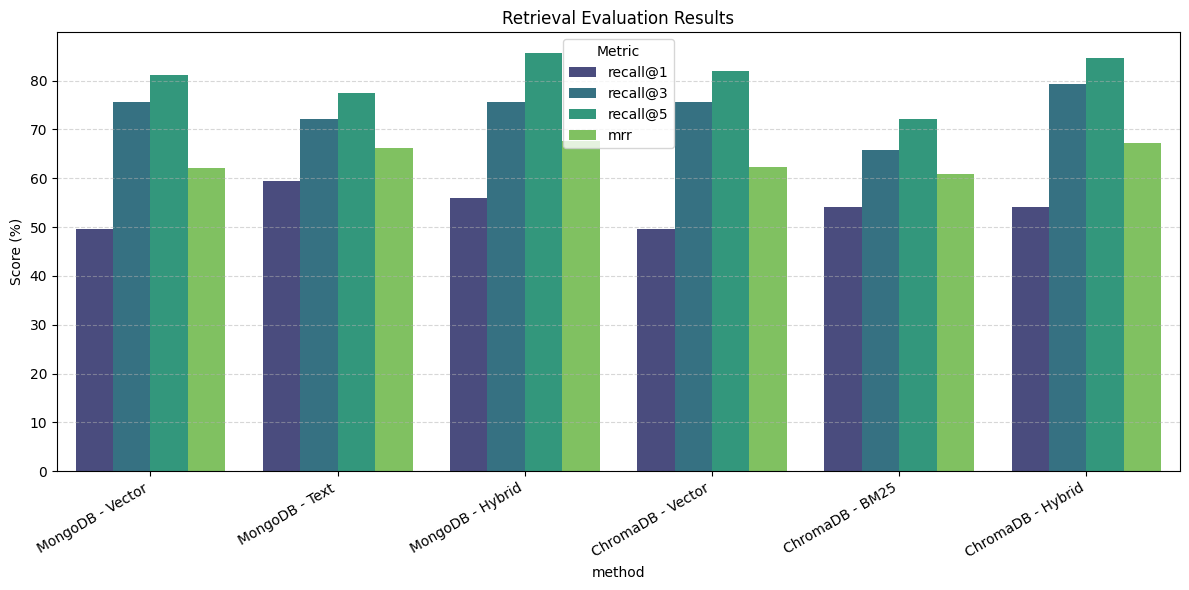

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

# ===== JSON 불러오기 =====
file_name = "safe_sql"
json_file = f"/home/ljm/test_chunk/evaluation_results/{file_name}_evaluation_results.json"
with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)

# ===== DataFrame 변환 =====
df = pd.DataFrame(data)
df_melt = df.melt(id_vars="method", 
                  value_vars=["recall@1", "recall@3", "recall@5", "mrr"],
                  var_name="Metric", value_name="Score")

# MRR을 % 단위로 맞춤
df_melt.loc[df_melt["Metric"] == "mrr", "Score"] *= 100

# ===== 시각화 =====
plt.figure(figsize=(12,6))
sns.barplot(data=df_melt, x="method", y="Score", hue="Metric", palette="viridis")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Score (%)")
plt.title("Retrieval Evaluation Results")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


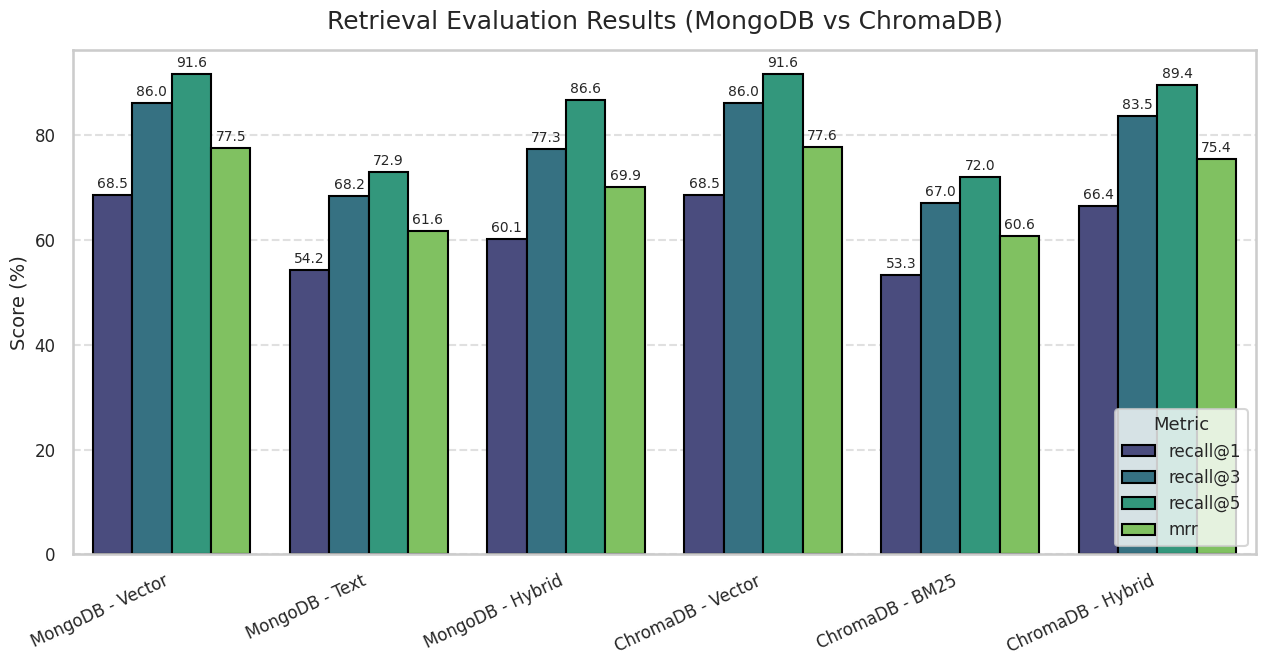

In [11]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===== JSON 로드 =====
file_name = "국방부_업무보고"
json_file = f"/home/ljm/test_chunk/evaluation_results/{file_name}_evaluation_results.json"
with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)

# ===== DataFrame 변환 =====
df = pd.DataFrame(data)

# MRR도 % 단위로 통일
df["mrr"] = df["mrr"] * 100

# "recall@1", "recall@3", "recall@5", "mrr"을 long-form으로 변환
df_melt = df.melt(
    id_vars="method",
    value_vars=["recall@1", "recall@3", "recall@5", "mrr"],
    var_name="Metric",
    value_name="Score"
)

# ===== 시각화 =====
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(13, 7))
ax = sns.barplot(
    data=df_melt,
    x="method",
    y="Score",
    hue="Metric",
    palette="viridis",
    edgecolor="black"
)

# ===== 그래프 꾸미기 =====
plt.title("Retrieval Evaluation Results (MongoDB vs ChromaDB)", fontsize=18, pad=15)
plt.ylabel("Score (%)", fontsize=14)
plt.xlabel("")
plt.xticks(rotation=25, ha="right", fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Metric", fontsize=12, title_fontsize=13, loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# 막대 위에 수치 표시
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=10, padding=3)

plt.tight_layout()
plt.show()
